# ================================================
# FILE 3: PERANCANGAN & PELATIHAN MODEL LSTM
# ================================================
# Penelitian : Perbandingan LSTM vs Bi-LSTM untuk Analisis
#              Sentimen MBG
# Model      : Long Short-Term Memory (LSTM)
# Pengujian  : 4 Skenario (variasi epoch & units)
# Platform   : Google Colab
# ================================================

# BAGIAN 0 — SETUP & INSTALASI

In [ ]:

# ============================================================
# BAGIAN 0 — SETUP & INSTALASI
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM,
    Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score,
    recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# WAJIB IDENTIK dengan file Bi-LSTM
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("=" * 70)
print("SETUP & LIBRARY BERHASIL DIMUAT")
print("=" * 70)
print(f"TensorFlow version : {tf.__version__}")

from google.colab import drive
drive.mount('/content/drive')

# Path — IDENTIK dengan file Bi-LSTM
BASE_DIR  = '/content/drive/MyDrive/skripsi_mbg'
EMBED_DIR = f'{BASE_DIR}/data/embeddings'
LSTM_DIR  = f'{BASE_DIR}/results_lstm'

os.makedirs(LSTM_DIR, exist_ok=True)
os.makedirs(f'{LSTM_DIR}/plots', exist_ok=True)
os.makedirs(f'{LSTM_DIR}/models', exist_ok=True)

print(f"\n✅ Direktori output : {LSTM_DIR}")

SETUP & LIBRARY BERHASIL DIMUAT
TensorFlow version : 2.20.0
Mounted at /content/drive

✅ Direktori output : /content/drive/MyDrive/skripsi_mbg/results_lstm


# BAGIAN 1 — LOAD DATA HASIL EMBEDDING

In [ ]:

# ============================================================
# BAGIAN 1 — LOAD DATA HASIL EMBEDDING
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 1: LOAD DATA (IDENTIK DENGAN FILE BI-LSTM)")
print("=" * 70)

# Load X dan y
X = np.load(f'{EMBED_DIR}/X_padded_sequences.npy')
y = np.load(f'{EMBED_DIR}/y_onehot_labels.npy')

# Load label encoder
with open(f'{EMBED_DIR}/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Load tokenizer
with open(f'{EMBED_DIR}/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

# Load metadata
with open(f'{EMBED_DIR}/embedding_metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"✅ Data berhasil dimuat!")
print(f"\nDimensi Data:")
print(f"  X shape : {X.shape} (jumlah_tweet × MAX_LENGTH)")
print(f"  y shape : {y.shape} (jumlah_tweet × num_classes)")
print(f"\nInformasi Label:")
print(f"  Kelas   : {le.classes_.tolist()}")

y_classes = np.argmax(y, axis=1)
unique, counts = np.unique(y_classes, return_counts=True)

print(f"\nDistribusi Kelas:")
for cls_idx, cnt in zip(unique, counts):
    print(f"  {le.classes_[cls_idx]:<10} ({cls_idx}): "
          f"{cnt:>4} samples ({cnt/len(y)*100:.1f}%)")



BAGIAN 1: LOAD DATA (IDENTIK DENGAN FILE BI-LSTM)
✅ Data berhasil dimuat!

Dimensi Data:
  X shape : (2245, 50) (jumlah_tweet × MAX_LENGTH)
  y shape : (2245, 3) (jumlah_tweet × num_classes)

Informasi Label:
  Kelas   : ['NEGATIVE', 'NEUTRAL', 'POSITIVE']

Distribusi Kelas:
  NEGATIVE   (0):  721 samples (32.1%)
  NEUTRAL    (1):  168 samples (7.5%)
  POSITIVE   (2): 1356 samples (60.4%)


# BAGIAN 2 — SPLIT DATA TRAIN & TEST

In [ ]:
# ============================================================
# BAGIAN 2 — SPLIT DATA TRAIN & TEST
# ============================================================
# WAJIB IDENTIK dengan file Bi-LSTM
# random_state=42, test_size=0.2, stratify=y_classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    stratify     = y_classes,
    random_state = RANDOM_STATE
)

print(f"✅ Pembagian data berhasil!")
print(f"\nUkuran Data:")
print(f"  Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

# Split validation dari train set — IDENTIK dengan Bi-LSTM
y_train_classes = np.argmax(y_train, axis=1)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size    = 0.2,
    stratify     = y_train_classes,
    random_state = RANDOM_STATE
)

print(f"\nSplit tambahan untuk validation:")
print(f"  X_tr (train aktual) : {X_tr.shape[0]} samples")
print(f"  X_val (validation)  : {X_val.shape[0]} samples")

print(f"\nDistribusi kelas di Test set:")
y_test_classes = np.argmax(y_test, axis=1)
for cls_idx in unique:
    cnt = np.sum(y_test_classes == cls_idx)
    print(f"  {le.classes_[cls_idx]:<10}: {cnt:>3} ({cnt/len(y_test)*100:.1f}%)")

print(f"\n⚠️ Pastikan angka di atas SAMA dengan file Bi-LSTM!")

✅ Pembagian data berhasil!

Ukuran Data:
  Train : 1796 samples (80%)
  Test  : 449 samples (20%)

Split tambahan untuk validation:
  X_tr (train aktual) : 1436 samples
  X_val (validation)  : 360 samples

Distribusi kelas di Test set:
  NEGATIVE  : 144 (32.1%)
  NEUTRAL   :  34 (7.6%)
  POSITIVE  : 271 (60.4%)

⚠️ Pastikan angka di atas SAMA dengan file Bi-LSTM!


## BAGIAN 2B — OVERSAMPLE KELAS NEUTRAL (TAMBAHAN BARU)

In [ ]:
# ============================================================
# BAGIAN 2B — OVERSAMPLE TRAIN & PERBAIKI VAL SET
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 2B: OVERSAMPLE TRAIN DAN PERBAIKI VAL SET")
print("=" * 70)

y_tr_classes  = np.argmax(y_tr, axis=1)
y_val_classes = np.argmax(y_val, axis=1)

# --- Cek distribusi sebelum ---
print(f"Distribusi TRAIN sebelum oversample:")
for cls_idx in range(3):
    cnt = np.sum(y_tr_classes == cls_idx)
    print(f"  {le.classes_[cls_idx]:<10}: {cnt} samples")

print(f"\nDistribusi VAL sebelum oversample:")
for cls_idx in range(3):
    cnt = np.sum(y_val_classes == cls_idx)
    print(f"  {le.classes_[cls_idx]:<10}: {cnt} samples")

# --- Oversample TRAIN ---
np.random.seed(RANDOM_STATE)

idx_neg_tr = np.where(y_tr_classes == 0)[0]
idx_neu_tr = np.where(y_tr_classes == 1)[0]
idx_pos_tr = np.where(y_tr_classes == 2)[0]

# Target: NEUTRAL naik ke 350, yang lain tetap
idx_neu_tr_over = np.random.choice(idx_neu_tr, size=350, replace=True)
all_idx_tr = np.concatenate([idx_neg_tr, idx_neu_tr_over, idx_pos_tr])
np.random.shuffle(all_idx_tr)

X_tr_resampled = X_tr[all_idx_tr]
y_tr_resampled = y_tr[all_idx_tr]

# --- Oversample VAL (lebih ringan, hanya duplikasi) ---
idx_neg_val = np.where(y_val_classes == 0)[0]
idx_neu_val = np.where(y_val_classes == 1)[0]
idx_pos_val = np.where(y_val_classes == 2)[0]

# Target: NEUTRAL val naik ke 60
idx_neu_val_over = np.random.choice(idx_neu_val, size=60, replace=True)
all_idx_val = np.concatenate([idx_neg_val, idx_neu_val_over, idx_pos_val])
np.random.shuffle(all_idx_val)

X_val_resampled = X_val[all_idx_val]
y_val_resampled = y_val[all_idx_val]

# --- Cetak hasil ---
y_tr_res_cls  = np.argmax(y_tr_resampled, axis=1)
y_val_res_cls = np.argmax(y_val_resampled, axis=1)

print(f"\nDistribusi TRAIN setelah oversample:")
for cls_idx in range(3):
    cnt = np.sum(y_tr_res_cls == cls_idx)
    print(f"  {le.classes_[cls_idx]:<10}: {cnt} samples")

print(f"\nDistribusi VAL setelah oversample:")
for cls_idx in range(3):
    cnt = np.sum(y_val_res_cls == cls_idx)
    print(f"  {le.classes_[cls_idx]:<10}: {cnt} samples")

print(f"\n✅ X_tr_resampled  : {X_tr_resampled.shape}")
print(f"✅ y_tr_resampled  : {y_tr_resampled.shape}")
print(f"✅ X_val_resampled : {X_val_resampled.shape}")
print(f"✅ y_val_resampled : {y_val_resampled.shape}")
print(f"\n⚠️  Test set TIDAK disentuh — evaluasi tetap pada data asli")


BAGIAN 2B: OVERSAMPLE TRAIN DAN PERBAIKI VAL SET
Distribusi TRAIN sebelum oversample:
  NEGATIVE  : 461 samples
  NEUTRAL   : 107 samples
  POSITIVE  : 868 samples

Distribusi VAL sebelum oversample:
  NEGATIVE  : 116 samples
  NEUTRAL   : 27 samples
  POSITIVE  : 217 samples

Distribusi TRAIN setelah oversample:
  NEGATIVE  : 461 samples
  NEUTRAL   : 350 samples
  POSITIVE  : 868 samples

Distribusi VAL setelah oversample:
  NEGATIVE  : 116 samples
  NEUTRAL   : 60 samples
  POSITIVE  : 217 samples

✅ X_tr_resampled  : (1679, 50)
✅ y_tr_resampled  : (1679, 3)
✅ X_val_resampled : (393, 50)
✅ y_val_resampled : (393, 3)

⚠️  Test set TIDAK disentuh — evaluasi tetap pada data asli


# BAGIAN 3 — PARAMETER MODEL & SKENARIO

In [ ]:
# ============================================================
# BAGIAN 3 — PARAMETER MODEL & SKENARIO
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 3: PARAMETER MODEL & SKENARIO")
print("=" * 70)

# Ambil dari metadata — IDENTIK dengan Bi-LSTM
VOCAB_SIZE    = metadata['VOCAB_SIZE']    # 5000
EMBEDDING_DIM = metadata['EMBEDDING_DIM'] # 128
MAX_LENGTH    = metadata['MAX_LENGTH']    # 50
NUM_CLASSES   = metadata['NUM_CLASSES']  # 3

# Parameter training — IDENTIK dengan Bi-LSTM
BATCH_SIZE    = 32
LEARNING_RATE = 0.001
DROPOUT_RATE  = 0.5

# Skenario — IDENTIK dengan Bi-LSTM
SKENARIO = [
    {'id': 1, 'nama': 'Skenario 1', 'epoch': 50,  'units': 64,
     'label': 'Epoch=50,  Units=64'},
    {'id': 2, 'nama': 'Skenario 2', 'epoch': 75,  'units': 64,
     'label': 'Epoch=75,  Units=64'},
    {'id': 3, 'nama': 'Skenario 3', 'epoch': 100, 'units': 64,
     'label': 'Epoch=100, Units=64'},
    {'id': 4, 'nama': 'Skenario 4', 'epoch': 100, 'units': 128,
     'label': 'Epoch=100, Units=128'},
]

print(f"Parameter Model LSTM (dari metadata, IDENTIK dengan Bi-LSTM):")
print(f"  VOCAB_SIZE    : {VOCAB_SIZE}")
print(f"  EMBEDDING_DIM : {EMBEDDING_DIM}")
print(f"  MAX_LENGTH    : {MAX_LENGTH}")
print(f"  NUM_CLASSES   : {NUM_CLASSES}")
print(f"  BATCH_SIZE    : {BATCH_SIZE}")
print(f"  LEARNING_RATE : {LEARNING_RATE}")
print(f"  DROPOUT_RATE  : {DROPOUT_RATE}")
print(f"  RANDOM_STATE  : {RANDOM_STATE}")

print(f"\n  PERBEDAAN SATU-SATUNYA:")
print(f"  File Bi-LSTM → layer: Bidirectional(LSTM(units))")
print(f"  File ini     → layer: LSTM(units)")

print(f"\n{'='*70}")
print(f"{'No':<5} {'Nama':<15} {'Epoch':<10} {'Units':<10} {'Keterangan'}")
print(f"{'='*70}")
for s in SKENARIO:
    print(f"  {s['id']:<5} {s['nama']:<15} "
          f"{s['epoch']:<10} {s['units']:<10} {s['label']}")
print(f"{'='*70}")


BAGIAN 3: PARAMETER MODEL & SKENARIO
Parameter Model LSTM (dari metadata, IDENTIK dengan Bi-LSTM):
  VOCAB_SIZE    : 7000
  EMBEDDING_DIM : 128
  MAX_LENGTH    : 50
  NUM_CLASSES   : 3
  BATCH_SIZE    : 32
  LEARNING_RATE : 0.001
  DROPOUT_RATE  : 0.5
  RANDOM_STATE  : 42

  PERBEDAAN SATU-SATUNYA:
  File Bi-LSTM → layer: Bidirectional(LSTM(units))
  File ini     → layer: LSTM(units)

No    Nama            Epoch      Units      Keterangan
  1     Skenario 1      50         64         Epoch=50,  Units=64
  2     Skenario 2      75         64         Epoch=75,  Units=64
  3     Skenario 3      100        64         Epoch=100, Units=64
  4     Skenario 4      100        128        Epoch=100, Units=128


# BAGIAN 4 — FUNGSI BUILD MODEL LSTM

In [ ]:
# ============================================================
# BAGIAN 4 — FUNGSI BUILD MODEL LSTM
# ============================================================
"""
Arsitektur LSTM untuk klasifikasi sentimen 3 kelas.

Perbedaan LSTM vs Bi-LSTM:
  LSTM    : memproses urutan SATU arah (token[0] → token[n])
  Bi-LSTM : memproses DUA arah sekaligus (forward + backward)

Susunan layer (IDENTIK dengan Bi-LSTM kecuali layer 3):
  1. Embedding        : integer → dense vector
  2. SpatialDropout1D : regularisasi khusus sequence data
  3. LSTM             : proses satu arah  ← PERBEDAAN
  4. Dropout          : regularisasi
  5. Dense (ReLU)     : hidden layer
  6. Dropout          : regularisasi
  7. Dense (Softmax)  : output 3 kelas
"""

def build_lstm_model(vocab_size, embedding_dim, max_length,
                     lstm_units, num_classes, dropout_rate, learning_rate):
    model = Sequential(name=f'LSTM_{lstm_units}units')

    # Layer 1: Embedding
    model.add(Embedding(input_dim=vocab_size + 1, output_dim=embedding_dim,
                        input_length=max_length, name='embedding_layer'))

    # Layer 2: Spatial Dropout (regularisasi khusus sequence data)
    model.add(SpatialDropout1D(rate=0.2, name='spatial_dropout'))

    # Layer 3: LSTM (satu arah)
    model.add(LSTM(units=lstm_units,
                   dropout=0.2,
                   recurrent_dropout=0.1,
                   return_sequences=False,  # Wajib False jika hanya 1 lapis
                   name=f'lstm_{lstm_units}units'))

    # Layer 4: Dropout setelah LSTM
    model.add(Dropout(0.3, name='dropout_after_lstm'))

    # Layer 5: Dense Hidden
    model.add(Dense(units=64, activation='relu', name='dense_hidden'))

    # Layer 6: Dropout setelah Dense
    model.add(Dropout(0.2, name='dropout_after_dense'))

    # Layer 7: Output
    model.add(Dense(units=num_classes, activation='softmax', name='output_layer'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


# Tampilkan arsitektur contoh
print("\n" + "=" * 70)
print("BAGIAN 4: ARSITEKTUR MODEL LSTM (CONTOH SKENARIO 1)")
print("=" * 70)

sample_model = build_lstm_model(
    VOCAB_SIZE, EMBEDDING_DIM, MAX_LENGTH,
    SKENARIO[0]['units'], NUM_CLASSES,
    DROPOUT_RATE, LEARNING_RATE
)
sample_model.build(input_shape=(None, MAX_LENGTH))
sample_model.summary()

print(f"\nCatatan: LSTM output shape = (None, units)")
print(f"  Berbeda dengan Bi-LSTM yang outputnya (None, units×2)")
print(f"  units=32  → LSTM output (None, 32)  | Bi-LSTM (None, 64)")
print(f"  units=64  → LSTM output (None, 64)  | Bi-LSTM (None, 128)")
print(f"  units=128 → LSTM output (None, 128) | Bi-LSTM (None, 256)")


BAGIAN 4: ARSITEKTUR MODEL LSTM (CONTOH SKENARIO 1)


Model: "LSTM_64units"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 50, 128)        │       896,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 50, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_64units (LSTM)             │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_after_lstm (Dropout)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_after_dense (Dropout)   │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 949,891 (3.62 MB)

 Trainable params: 949,891 (3.62 MB)

 Non-trainable params: 0 (0.00 B)


Catatan: LSTM output shape = (None, units)
  Berbeda dengan Bi-LSTM yang outputnya (None, units×2)
  units=32  → LSTM output (None, 32)  | Bi-LSTM (None, 64)
  units=64  → LSTM output (None, 64)  | Bi-LSTM (None, 128)
  units=128 → LSTM output (None, 128) | Bi-LSTM (None, 256)


# BAGIAN 5 — FUNGSI EVALUASI DAN VISUALISASI

In [ ]:
# ============================================================
# BAGIAN 5 — FUNGSI EVALUASI DAN VISUALISASI
# ============================================================
def evaluate_model(model, X_test, y_test, le, skenario_id, skenario_nama):
    """
    Evaluasi model LSTM secara komprehensif.
    Fungsi IDENTIK dengan file Bi-LSTM untuk konsistensi.
    """
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = np.argmax(y_test, axis=1)

    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_per_class    = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class        = f1_score(y_true, y_pred, average=None, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(
        y_true, y_pred,
        target_names=le.classes_,
        output_dict=True
    )

    results = {
        'model'       : 'LSTM',
        'skenario_id' : skenario_id,
        'skenario'    : skenario_nama,
        'accuracy'    : round(acc, 4),
        'precision'   : round(precision, 4),
        'recall'      : round(recall, 4),
        'f1_score'    : round(f1, 4),
        'confusion_matrix'       : cm.tolist(),
        'classification_report'  : cr,
    }

    for i, cls in enumerate(le.classes_):
        results[f'precision_{cls}'] = round(precision_per_class[i], 4)
        results[f'recall_{cls}']    = round(recall_per_class[i], 4)
        results[f'f1_{cls}']        = round(f1_per_class[i], 4)

    return results, cm, y_pred, y_true


def plot_confusion_matrix(cm, le, skenario_nama, save_path):
    """Plot confusion matrix dengan warna biru (khas LSTM)."""
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_,
        ax=ax, linewidths=0.5
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(
        f'Confusion Matrix LSTM — {skenario_nama}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_training_history(history, skenario_nama, save_path):
    """Plot training & validation accuracy/loss per epoch."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'Training History LSTM — {skenario_nama}',
        fontsize=13, fontweight='bold'
    )

    epochs_range = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    axes[0].plot(epochs_range, history.history['accuracy'],
                 'b-o', label='Train Accuracy', markersize=4)
    axes[0].plot(epochs_range, history.history['val_accuracy'],
                 'r-o', label='Val Accuracy', markersize=4)
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Accuracy', fontsize=11)
    axes[0].set_title('Model Accuracy', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1])

    # Loss
    axes[1].plot(epochs_range, history.history['loss'],
                 'b-o', label='Train Loss', markersize=4)
    axes[1].plot(epochs_range, history.history['val_loss'],
                 'r-o', label='Val Loss', markersize=4)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Loss', fontsize=11)
    axes[1].set_title('Model Loss', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


print("✅ Semua fungsi evaluasi dan visualisasi siap")

✅ Semua fungsi evaluasi dan visualisasi siap


# BAGIAN 6 — TRAINING & EVALUASI 4 SKENARIO


BAGIAN 6: TRAINING & EVALUASI MODEL LSTM

  SKENARIO 1: Epoch=50,  Units=64

  [1/4] Membangun arsitektur model...
  ✅ Model berhasil dibangun
  ✅ Total parameters : 949,891
  ✅ LSTM output size : 64 (vs Bi-LSTM: 128)

  [2/4] Setup callbacks...
  ✅ EarlyStopping (patience=5) aktif
  ✅ ModelCheckpoint → /content/drive/MyDrive/skripsi_mbg/results_lstm/models/lstm_skenario1_best.h5

  Class weights:
    Class 0 (NEGATIVE  ): 1.0383
    Class 1 (NEUTRAL   ): 4.4735
    Class 2 (POSITIVE  ): 0.5515

  [3/4] Training (max 50 epoch)...
Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.5068 - loss: 1.0555

53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 243ms/step - accuracy: 0.5158 - loss: 1.0381 - val_accuracy: 0.5522 - val_loss: 0.9801
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 235ms/step - accuracy: 0.5170 - loss: 1.0289 - val_accuracy: 0.5522 - val_loss: 0.9810
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.5170 - loss: 1.0315 - val_accuracy: 0.5522 - val_loss: 0.9837
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.5113 - loss: 1.0309

53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 237ms/step - accuracy: 0.5170 - loss: 1.0264 - val_accuracy: 0.5522 - val_loss: 0.9777
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.5605 - loss: 0.9242

53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 223ms/step - accuracy: 0.5873 - loss: 0.8943 - val_accuracy: 0.6285 - val_loss: 0.9592
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - accuracy: 0.6450 - loss: 0.8243 - val_accuracy: 0.6412 - val_loss: 0.9846
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.6349 - loss: 0.8090 - val_accuracy: 0.4860 - val_loss: 1.0333
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.5718 - loss: 0.8017 - val_accuracy: 0.5115 - val_loss: 1.2035
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 215ms/step - accuracy: 0.6010 - loss: 0.7777 - val_accuracy: 0.5165 - val_loss: 1.1984
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - accuracy: 0.6444 - loss: 0.7673 - val_accuracy: 0.6260 - val_loss: 1.0303
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.6307 - loss: 0.8415 - val_accuracy: 0.5623 - val_loss: 0.9654
Epoch 12/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 212ms/step - accuracy: 0.5938 - loss: 0.9332 - val_accuracy: 0.

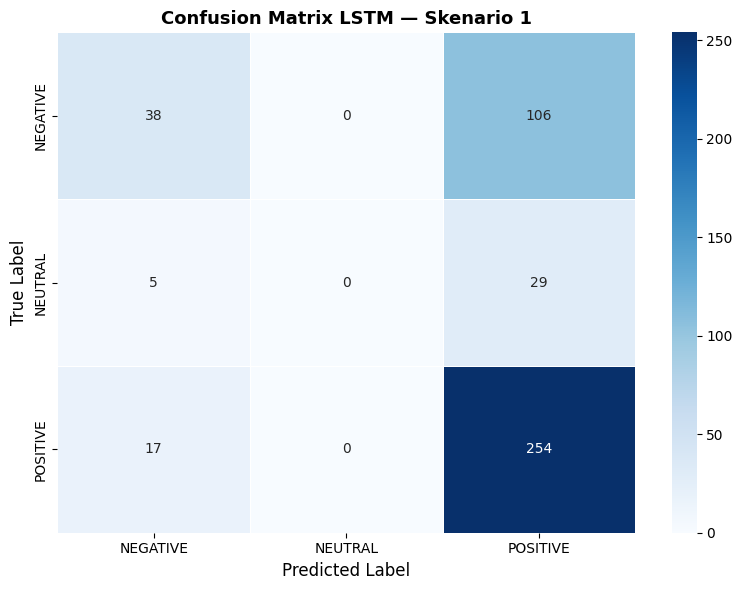

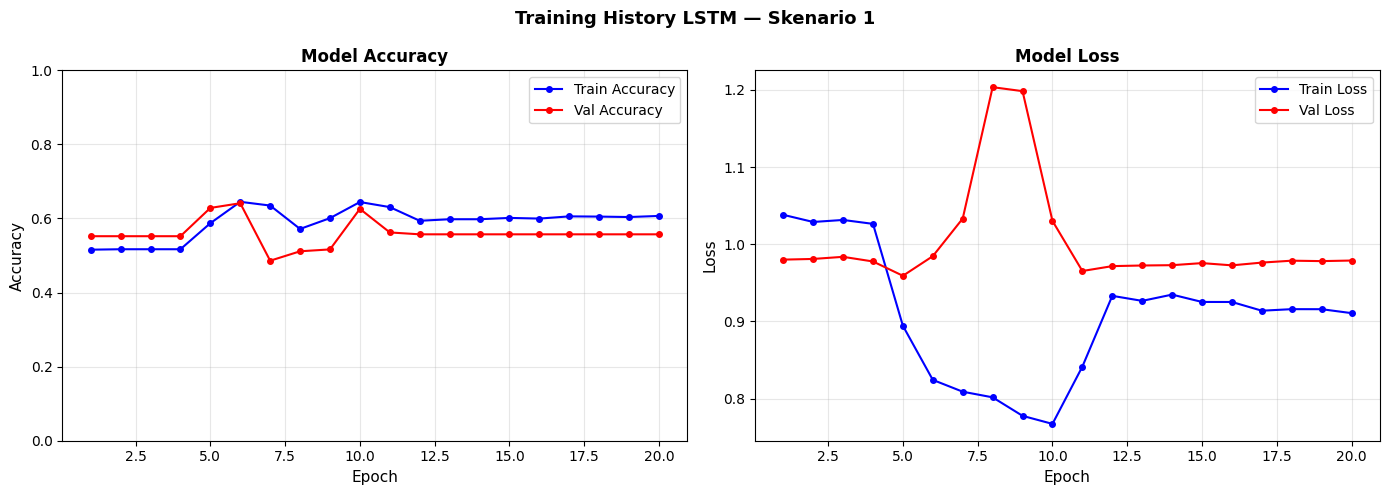


  ✅ Semua output Skenario 1 tersimpan

  SKENARIO 2: Epoch=75,  Units=64

  [1/4] Membangun arsitektur model...
  ✅ Model berhasil dibangun
  ✅ Total parameters : 949,891
  ✅ LSTM output size : 64 (vs Bi-LSTM: 128)

  [2/4] Setup callbacks...
  ✅ EarlyStopping (patience=5) aktif
  ✅ ModelCheckpoint → /content/drive/MyDrive/skripsi_mbg/results_lstm/models/lstm_skenario2_best.h5

  Class weights:
    Class 0 (NEGATIVE  ): 1.0383
    Class 1 (NEUTRAL   ): 4.4735
    Class 2 (POSITIVE  ): 0.5515

  [3/4] Training (max 75 epoch)...
Epoch 1/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.4942 - loss: 1.0514

53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 243ms/step - accuracy: 0.5128 - loss: 1.0362 - val_accuracy: 0.5522 - val_loss: 0.9785
Epoch 2/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 222ms/step - accuracy: 0.5170 - loss: 1.0330 - val_accuracy: 0.5522 - val_loss: 0.9842
Epoch 3/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 207ms/step - accuracy: 0.5170 - loss: 1.0278 - val_accuracy: 0.5522 - val_loss: 0.9859
Epoch 4/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.5192 - loss: 1.0145

53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 244ms/step - accuracy: 0.5331 - loss: 0.9673 - val_accuracy: 0.5522 - val_loss: 0.9658
Epoch 5/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 221ms/step - accuracy: 0.6051 - loss: 0.8790 - val_accuracy: 0.5522 - val_loss: 1.0069
Epoch 6/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step - accuracy: 0.6444 - loss: 0.8542 - val_accuracy: 0.5471 - val_loss: 1.0500
Epoch 7/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 220ms/step - accuracy: 0.6385 - loss: 0.8306 - val_accuracy: 0.6260 - val_loss: 0.9737
Epoch 8/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 218ms/step - accuracy: 0.6403 - loss: 0.8186 - val_accuracy: 0.6285 - val_loss: 0.9855
Epoch 9/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 222ms/step - accuracy: 0.6486 - loss: 0.7993 - val_accuracy: 0.6336 - val_loss: 1.0001
Epoch 10/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 196ms/step - accuracy: 0.6474 - loss: 0.7734 - val_accuracy: 0.6310 - val_loss: 1.0240
Epoch 11/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 213ms/step - accuracy: 0.6599 - loss: 0.7792 - val_accuracy: 0.5

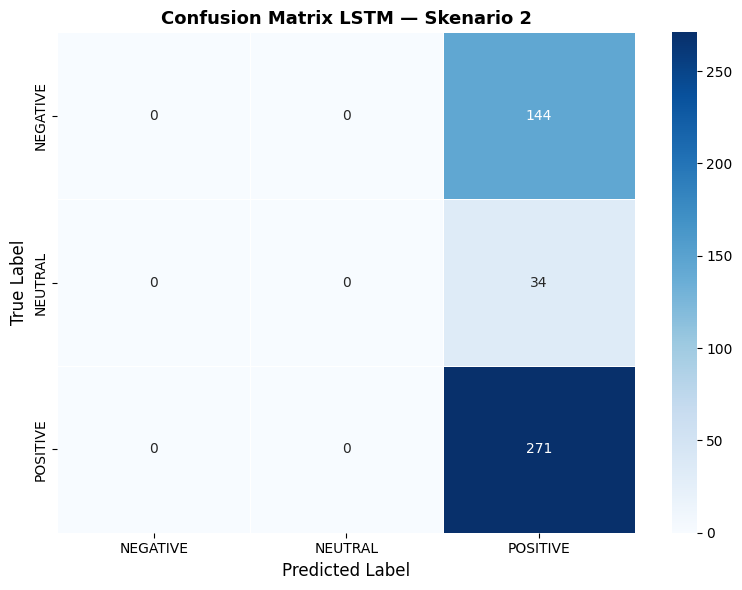

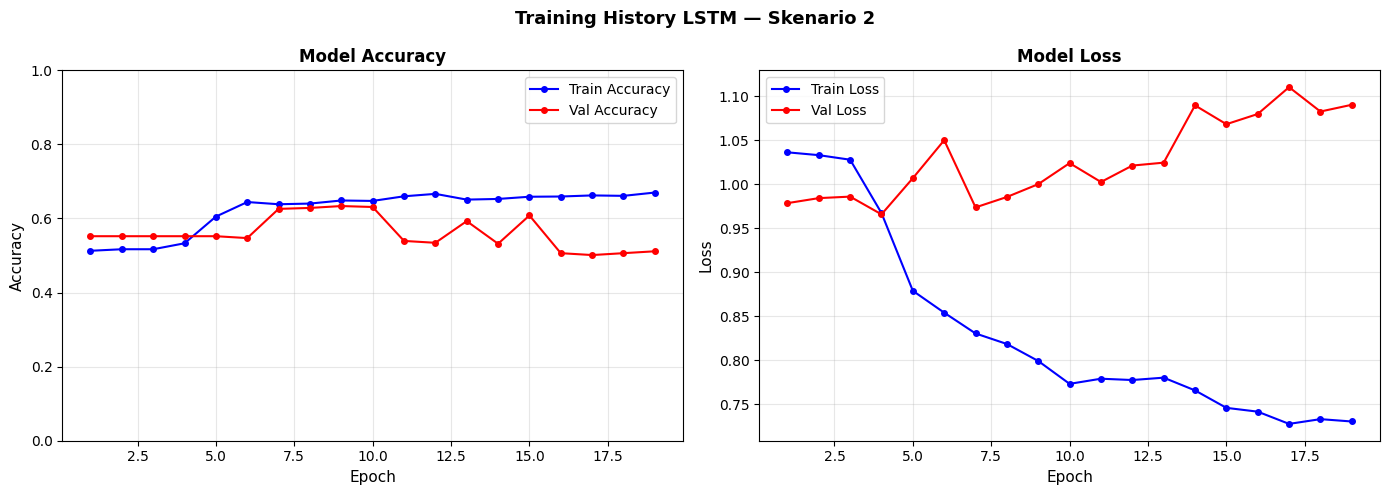


  ✅ Semua output Skenario 2 tersimpan

  SKENARIO 3: Epoch=100, Units=64

  [1/4] Membangun arsitektur model...
  ✅ Model berhasil dibangun
  ✅ Total parameters : 949,891
  ✅ LSTM output size : 64 (vs Bi-LSTM: 128)

  [2/4] Setup callbacks...
  ✅ EarlyStopping (patience=5) aktif
  ✅ ModelCheckpoint → /content/drive/MyDrive/skripsi_mbg/results_lstm/models/lstm_skenario3_best.h5

  Class weights:
    Class 0 (NEGATIVE  ): 1.0383
    Class 1 (NEUTRAL   ): 4.4735
    Class 2 (POSITIVE  ): 0.5515

  [3/4] Training (max 100 epoch)...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.4695 - loss: 1.0560

53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 247ms/step - accuracy: 0.5051 - loss: 1.0365 - val_accuracy: 0.5522 - val_loss: 0.9818
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step - accuracy: 0.5170 - loss: 1.0298 - val_accuracy: 0.5522 - val_loss: 0.9829
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5113 - loss: 1.0330

53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 227ms/step - accuracy: 0.5170 - loss: 1.0284 - val_accuracy: 0.5522 - val_loss: 0.9809
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.5113 - loss: 1.0409

53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 227ms/step - accuracy: 0.5176 - loss: 1.0300 - val_accuracy: 0.5522 - val_loss: 0.9794
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 226ms/step - accuracy: 0.5194 - loss: 1.0052 - val_accuracy: 0.5267 - val_loss: 1.0311
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.5575 - loss: 0.9818 - val_accuracy: 0.5547 - val_loss: 0.9853
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - accuracy: 0.5718 - loss: 0.9534 - val_accuracy: 0.5547 - val_loss: 0.9888
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.5741 - loss: 0.9463

53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 249ms/step - accuracy: 0.5777 - loss: 0.9418 - val_accuracy: 0.5522 - val_loss: 0.9762
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 231ms/step - accuracy: 0.5420 - loss: 1.0065 - val_accuracy: 0.5598 - val_loss: 0.9971
Epoch 10/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5743 - loss: 0.9681

53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 209ms/step - accuracy: 0.5789 - loss: 0.9612 - val_accuracy: 0.5598 - val_loss: 0.9718
Epoch 11/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.5813 - loss: 0.9559 - val_accuracy: 0.5598 - val_loss: 0.9751
Epoch 12/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.5896 - loss: 0.9426 - val_accuracy: 0.5573 - val_loss: 0.9791
Epoch 13/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - accuracy: 0.5932 - loss: 0.9376 - val_accuracy: 0.5573 - val_loss: 0.9841
Epoch 14/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.5938 - loss: 0.9380 - val_accuracy: 0.5573 - val_loss: 0.9840
Epoch 15/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 219ms/step - accuracy: 0.5986 - loss: 0.9288 - val_accuracy: 0.5573 - val_loss: 0.9886
Epoch 16/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.5986 - loss: 0.9260 - val_accuracy: 0.5598 - val_loss: 0.9830
Epoch 17/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 221ms/step - accuracy: 0.6004 - loss: 0.9249 - val_a

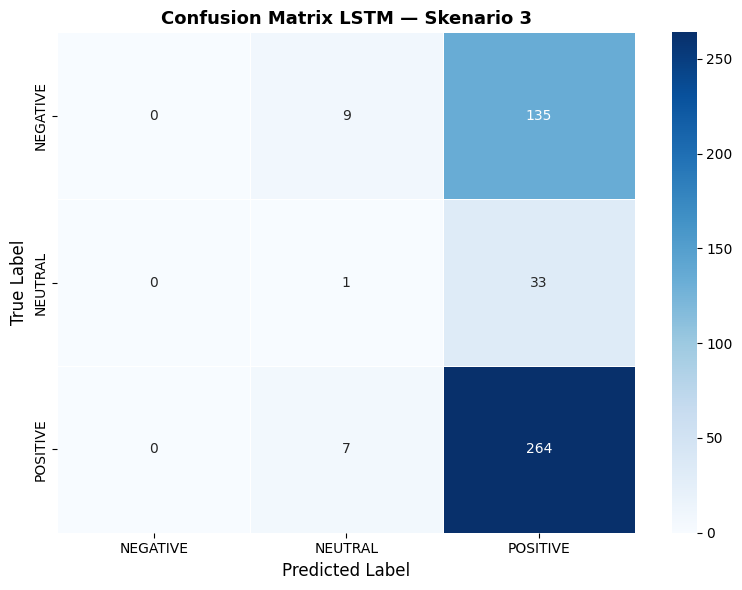

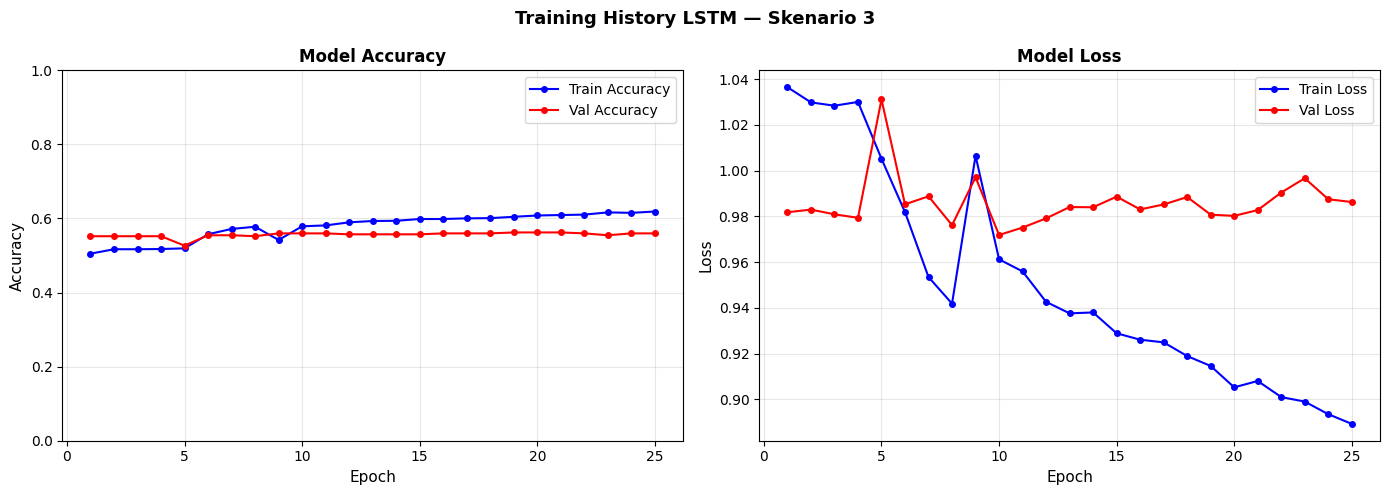


  ✅ Semua output Skenario 3 tersimpan

  SKENARIO 4: Epoch=100, Units=128

  [1/4] Membangun arsitektur model...
  ✅ Model berhasil dibangun
  ✅ Total parameters : 1,036,163
  ✅ LSTM output size : 128 (vs Bi-LSTM: 256)

  [2/4] Setup callbacks...
  ✅ EarlyStopping (patience=5) aktif
  ✅ ModelCheckpoint → /content/drive/MyDrive/skripsi_mbg/results_lstm/models/lstm_skenario4_best.h5

  Class weights:
    Class 0 (NEGATIVE  ): 1.0383
    Class 1 (NEUTRAL   ): 4.4735
    Class 2 (POSITIVE  ): 0.5515

  [3/4] Training (max 100 epoch)...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.4940 - loss: 1.0523

53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step - accuracy: 0.5128 - loss: 1.0375 - val_accuracy: 0.5522 - val_loss: 0.9865
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.5113 - loss: 1.0318

53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 245ms/step - accuracy: 0.5170 - loss: 1.0247 - val_accuracy: 0.5522 - val_loss: 0.9819
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 223ms/step - accuracy: 0.5170 - loss: 1.0271 - val_accuracy: 0.5522 - val_loss: 0.9830
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 228ms/step - accuracy: 0.5182 - loss: 1.0142 - val_accuracy: 0.4860 - val_loss: 0.9844
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.5223 - loss: 0.9618

53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 243ms/step - accuracy: 0.5456 - loss: 0.9104 - val_accuracy: 0.5242 - val_loss: 0.9785
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 225ms/step - accuracy: 0.5646 - loss: 0.9342 - val_accuracy: 0.5522 - val_loss: 0.9795
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 225ms/step - accuracy: 0.5825 - loss: 0.9320 - val_accuracy: 0.5471 - val_loss: 1.1473
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 220ms/step - accuracy: 0.6420 - loss: 0.8646 - val_accuracy: 0.5573 - val_loss: 1.0029
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 220ms/step - accuracy: 0.6420 - loss: 0.8150 - val_accuracy: 0.5420 - val_loss: 1.1193
Epoch 10/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.6796 - loss: 0.7782 - val_accuracy: 0.5522 - val_loss: 1.0689
Epoch 11/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.6820 - loss: 0.7488 - val_accuracy: 0.5522 - val_loss: 1.1196
Epoch 12/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 224ms/step - accuracy: 0.6879 - loss: 0.7640 - val_accur

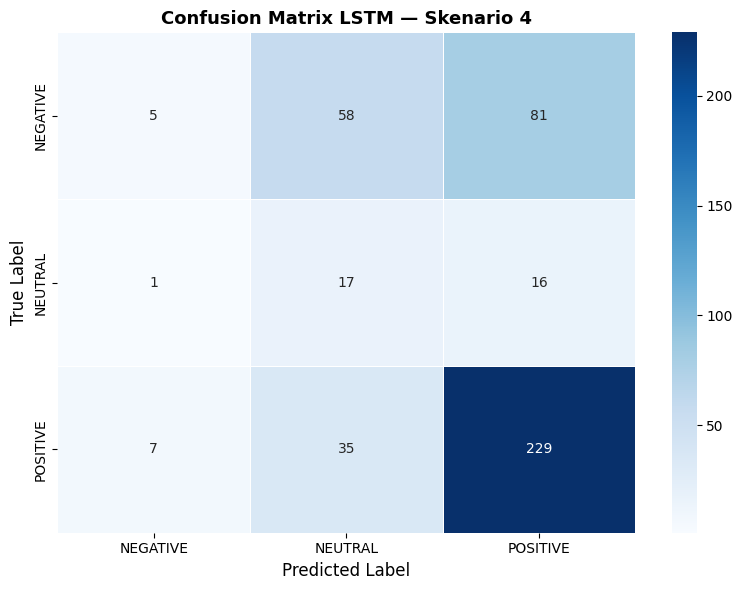

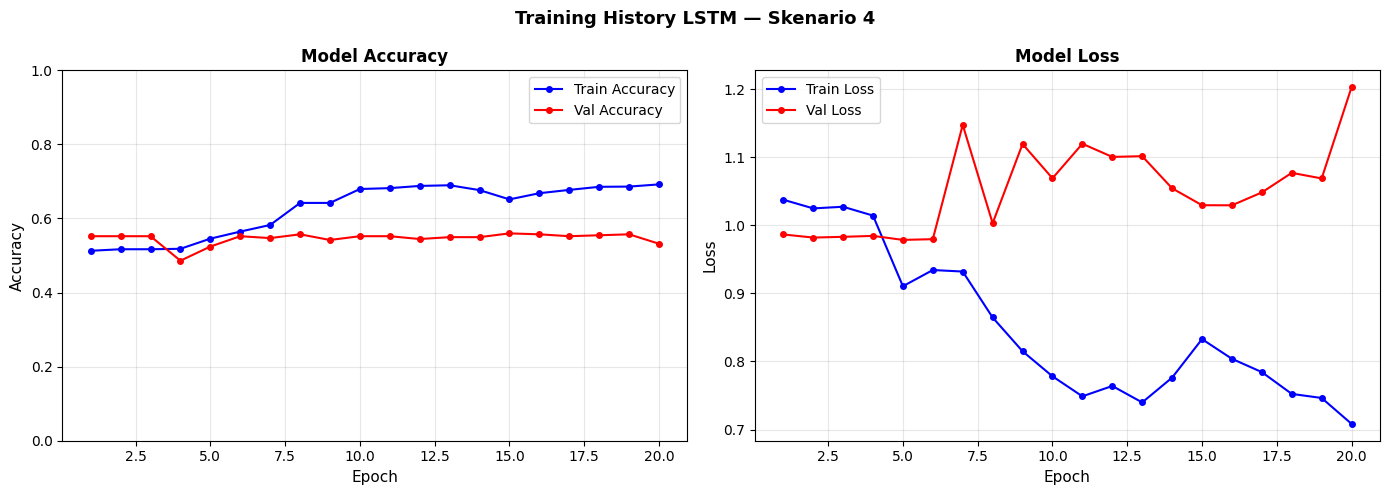


  ✅ Semua output Skenario 4 tersimpan


In [ ]:
# ============================================================
# BAGIAN 6 — TRAINING & EVALUASI 4 SKENARIO
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 6: TRAINING & EVALUASI MODEL LSTM")
print("=" * 70)

all_results   = []
all_histories = []

for skenario in SKENARIO:
    print(f"\n{'='*70}")
    print(f"  {skenario['nama'].upper()}: {skenario['label']}")
    print(f"{'='*70}")

    # -- 6.1 BUILD MODEL --
    print(f"\n  [1/4] Membangun arsitektur model...")
    tf.random.set_seed(RANDOM_STATE)

    model = build_lstm_model(
        vocab_size    = VOCAB_SIZE,
        embedding_dim = EMBEDDING_DIM,
        max_length    = MAX_LENGTH,
        lstm_units    = skenario['units'],
        num_classes   = NUM_CLASSES,
        dropout_rate  = DROPOUT_RATE,
        learning_rate = LEARNING_RATE
    )

    model.build(input_shape=(None, MAX_LENGTH))
    total_params = model.count_params()

    print(f"  ✅ Model berhasil dibangun")
    print(f"  ✅ Total parameters : {total_params:,}")
    print(f"  ✅ LSTM output size : {skenario['units']} "
          f"(vs Bi-LSTM: {skenario['units']*2})")

    # -- 6.2 CALLBACKS --
    print(f"\n  [2/4] Setup callbacks...")
    model_path = (f'{LSTM_DIR}/models/'
                  f'lstm_skenario{skenario["id"]}_best.h5')

    # Di bagian 6.2 CALLBACKS — ganti dengan:
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=15,           # naikkan kembali ke 15
            restore_best_weights=True,
            mode='min',
            min_delta=0.001,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )
    ]
    print(f"  ✅ EarlyStopping (patience=5) aktif")
    print(f"  ✅ ModelCheckpoint → {model_path}")

    # -- 6.3 HITUNG CLASS WEIGHT — IDENTIK dengan Bi-LSTM --
    y_tr_classes = np.argmax(y_tr, axis=1)
    weights = compute_class_weight(
        class_weight = 'balanced',
        classes      = np.unique(y_tr_classes),
        y            = y_tr_classes
    )
    CLASS_WEIGHT_DICT = dict(enumerate(weights))

    print(f"\n  Class weights:")
    for cls_idx, w in CLASS_WEIGHT_DICT.items():
        print(f"    Class {cls_idx} ({le.classes_[cls_idx]:<10}): {w:.4f}")

    # -- 6.4 TRAINING --
    print(f"\n  [3/4] Training (max {skenario['epoch']} epoch)...")

    # Di bagian 6.4 TRAINING — ganti validation_data:
    history = model.fit(
        X_tr_resampled, y_tr_resampled,
        epochs=skenario['epoch'],
        batch_size=BATCH_SIZE,
        validation_data=(X_val_resampled, y_val_resampled),  # ← pakai val yang sudah dibalancing
        callbacks=callbacks,
        verbose=1
    )

    actual_epochs    = len(history.history['accuracy'])
    final_train_acc  = history.history['accuracy'][-1]
    final_val_acc    = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss   = history.history['val_loss'][-1]

    print(f"\n  ✅ Training selesai ({actual_epochs} epoch dijalankan)")
    print(f"  ✅ Train Accuracy : {final_train_acc:.4f}")
    print(f"  ✅ Val Accuracy   : {final_val_acc:.4f}")
    print(f"  ✅ Train Loss     : {final_train_loss:.4f}")
    print(f"  ✅ Val Loss       : {final_val_loss:.4f}")

    # -- 6.5 EVALUASI --
    print(f"\n  [4/4] Evaluasi pada data TEST...")

    results, cm, y_pred, y_true = evaluate_model(
        model, X_test, y_test, le,
        skenario['id'], skenario['nama']
    )

    results.update({
        'epoch_digunakan' : actual_epochs,
        'epoch_maksimal'  : skenario['epoch'],
        'units'           : skenario['units'],
        'train_accuracy'  : round(final_train_acc, 4),
        'val_accuracy'    : round(final_val_acc, 4),
        'train_loss'      : round(final_train_loss, 4),
        'val_loss'        : round(final_val_loss, 4),
        'total_params'    : total_params,
    })

    # Tampilkan hasil
    print(f"\n  ┌{'─'*48}┐")
    print(f"  │ HASIL EVALUASI — {skenario['nama']:<28}│")
    print(f"  ├{'─'*48}┤")
    print(f"  │ Accuracy  : {results['accuracy']:.4f} "
          f"({results['accuracy']*100:.2f}%){'':>13}│")
    print(f"  │ Precision : {results['precision']:.4f}{'':>23}│")
    print(f"  │ Recall    : {results['recall']:.4f}{'':>23}│")
    print(f"  │ F1-Score  : {results['f1_score']:.4f}{'':>23}│")
    print(f"  └{'─'*48}┘")

    print(f"\n  Evaluasi per Kelas:")
    print(f"  {'Kelas':<12} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
    print(f"  {'-'*45}")
    for cls in le.classes_:
        print(f"  {cls:<12} "
              f"{results[f'precision_{cls}']:>10.4f} "
              f"{results[f'recall_{cls}']:>10.4f} "
              f"{results[f'f1_{cls}']:>10.4f}")

    # Simpan plot
    plot_confusion_matrix(
        cm, le, skenario['nama'],
        f'{LSTM_DIR}/plots/confusion_matrix_s{skenario["id"]}.png'
    )
    plot_training_history(
        history, skenario['nama'],
        f'{LSTM_DIR}/plots/training_history_s{skenario["id"]}.png'
    )

    all_results.append(results)
    all_histories.append({
        'skenario'    : skenario['nama'],
        'label'       : skenario['label'],
        'accuracy'    : history.history['accuracy'],
        'val_accuracy': history.history['val_accuracy'],
        'loss'        : history.history['loss'],
        'val_loss'    : history.history['val_loss'],
    })

    print(f"\n  ✅ Semua output Skenario {skenario['id']} tersimpan")

# BAGIAN 7 — RINGKASAN SEMUA SKENARIO

In [ ]:
# ============================================================
# BAGIAN 7 — RINGKASAN SEMUA SKENARIO
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 7: RINGKASAN SEMUA SKENARIO LSTM")
print("=" * 70)

df_results = pd.DataFrame(all_results)[[
    'skenario', 'epoch_digunakan', 'units',
    'accuracy', 'precision', 'recall', 'f1_score',
    'train_accuracy', 'val_accuracy'
]]
df_results.columns = [
    'Skenario', 'Epoch', 'Units',
    'Test Acc', 'Precision', 'Recall', 'F1-Score',
    'Train Acc', 'Val Acc'
]

print(f"\n{'='*85}")
print(df_results.to_string(index=False))
print(f"{'='*85}")

best_idx = df_results['Test Acc'].idxmax()
best_row = df_results.iloc[best_idx]

print(f"\n✅ SKENARIO TERBAIK : {best_row['Skenario']}")
print(f"   Test Accuracy    : {best_row['Test Acc']:.4f} "
      f"({best_row['Test Acc']*100:.2f}%)")
print(f"   F1-Score         : {best_row['F1-Score']:.4f}")


BAGIAN 7: RINGKASAN SEMUA SKENARIO LSTM

  Skenario  Epoch  Units  Test Acc  Precision  Recall  F1-Score  Train Acc  Val Acc
Skenario 1     20     64    0.6503     0.5972  0.6503    0.5840     0.6069   0.5573
Skenario 2     19     64    0.6036     0.3643  0.6036    0.4543     0.6700   0.5115
Skenario 3     25     64    0.5902     0.3733  0.5902    0.4563     0.6188   0.5598
Skenario 4     20    128    0.5590     0.5590  0.5590    0.5013     0.6921   0.5318

✅ SKENARIO TERBAIK : Skenario 1
   Test Accuracy    : 0.6503 (65.03%)
   F1-Score         : 0.5840


# BAGIAN 8 — VISUALISASI PERBANDINGAN ANTAR SKENARIO


BAGIAN 8: VISUALISASI PERBANDINGAN ANTAR SKENARIO


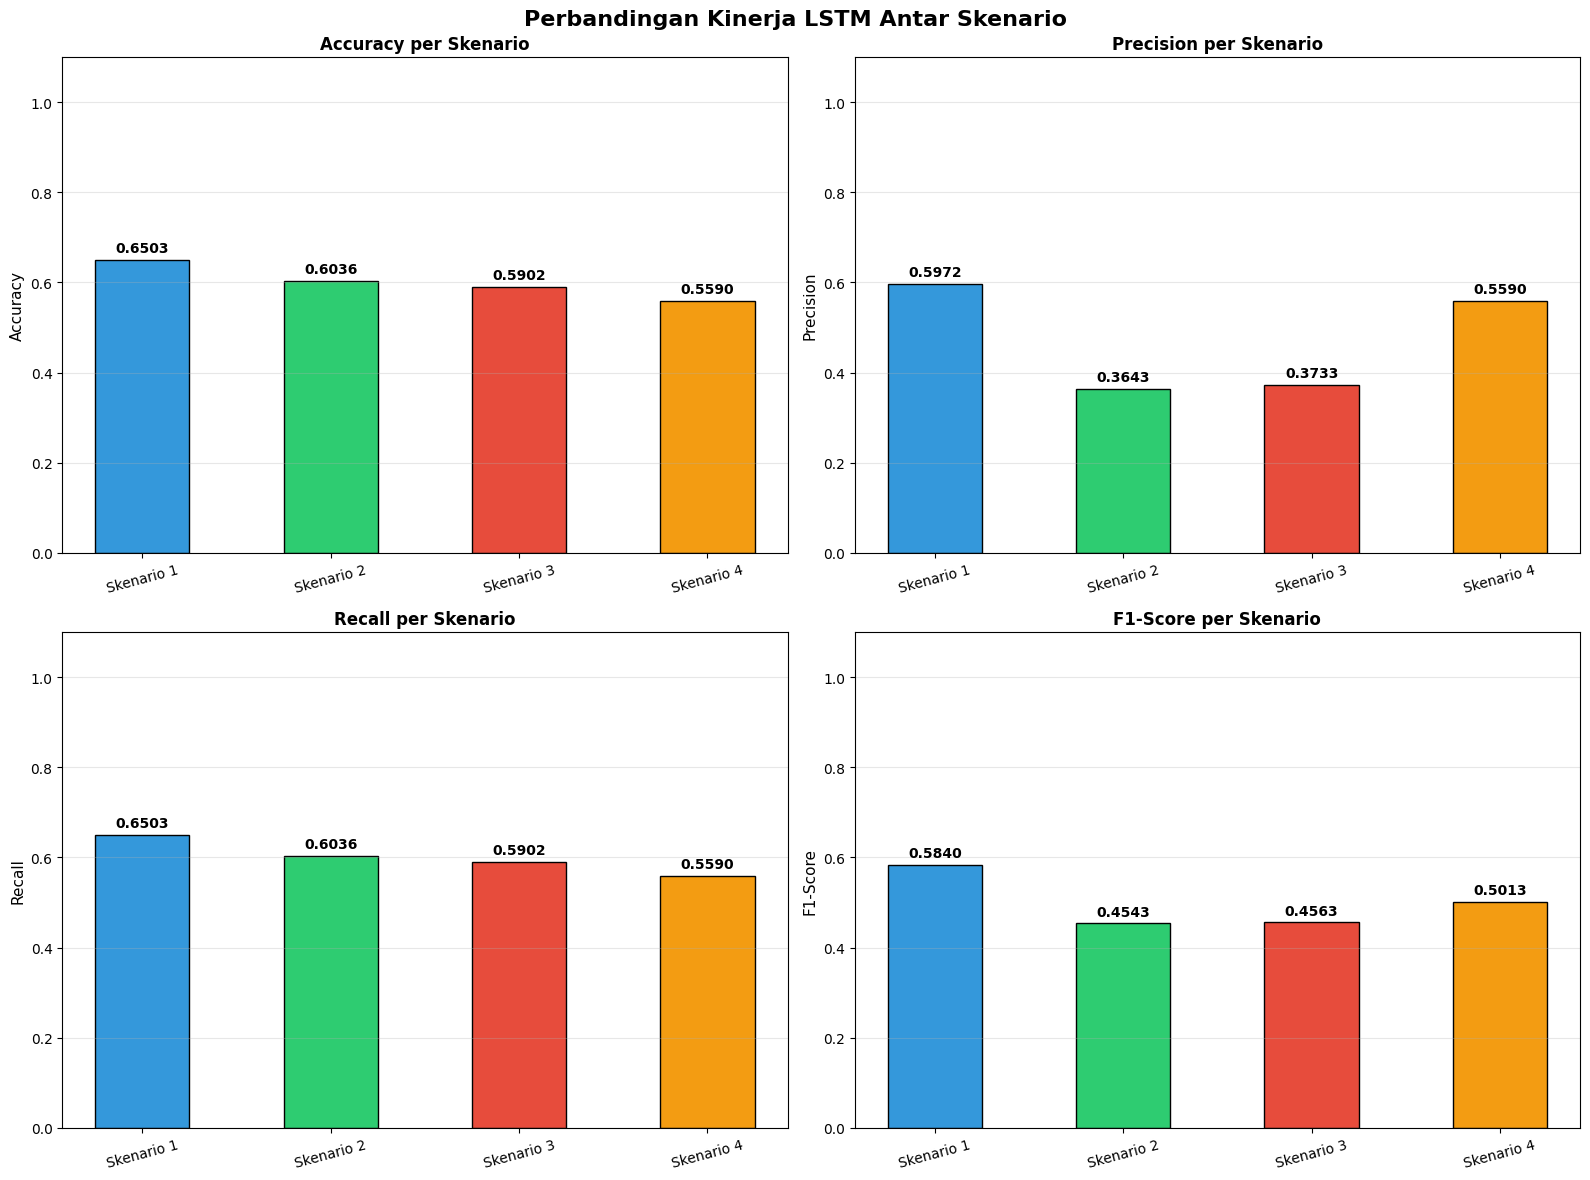

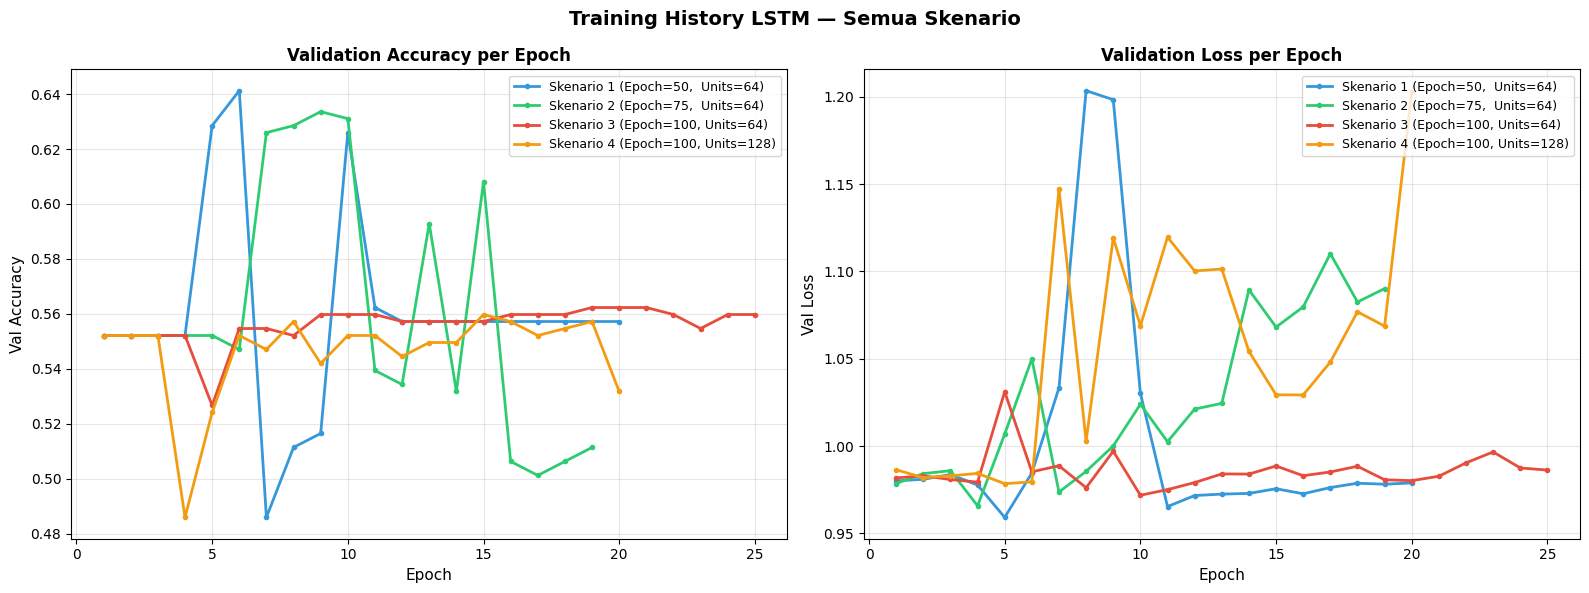

✅ Semua visualisasi tersimpan


In [ ]:
# ============================================================
# BAGIAN 8 — VISUALISASI PERBANDINGAN ANTAR SKENARIO
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 8: VISUALISASI PERBANDINGAN ANTAR SKENARIO")
print("=" * 70)

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

# Plot 1: Bar chart 4 metrik
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Perbandingan Kinerja LSTM Antar Skenario',
             fontsize=16, fontweight='bold')

skenario_labels = [r['skenario'] for r in all_results]
metrics_list    = ['accuracy', 'precision', 'recall', 'f1_score']
metric_titles   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, title) in enumerate(zip(metrics_list, metric_titles)):
    ax     = axes[idx // 2][idx % 2]
    values = [r[metric] for r in all_results]
    bars   = ax.bar(skenario_labels, values,
                    color=colors, edgecolor='black', width=0.5)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} per Skenario', fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

plt.tight_layout()
plt.savefig(f'{LSTM_DIR}/plots/comparison_all_scenarios.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Training history semua skenario
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training History LSTM — Semua Skenario',
             fontsize=14, fontweight='bold')

for idx, hist_data in enumerate(all_histories):
    epochs_range = range(1, len(hist_data['accuracy']) + 1)
    axes[0].plot(epochs_range, hist_data['val_accuracy'],
                 '-o', color=colors[idx],
                 label=f"{hist_data['skenario']} ({hist_data['label']})",
                 markersize=3, linewidth=2)
    axes[1].plot(epochs_range, hist_data['val_loss'],
                 '-o', color=colors[idx],
                 label=f"{hist_data['skenario']} ({hist_data['label']})",
                 markersize=3, linewidth=2)

for ax, ylabel, title in zip(
    axes,
    ['Val Accuracy', 'Val Loss'],
    ['Validation Accuracy per Epoch', 'Validation Loss per Epoch']
):
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{LSTM_DIR}/plots/training_history_all.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Semua visualisasi tersimpan")

# BAGIAN 9 — SIMPAN HASIL

In [ ]:
# ============================================================
# BAGIAN 9 — SIMPAN HASIL
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 9: SIMPAN HASIL")
print("=" * 70)

# Simpan CSV hasil
csv_path = f'{BASE_DIR}/data/results/results_lstm.csv'
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
pd.DataFrame(all_results).to_csv(csv_path, index=False)
print(f"✅ results_lstm.csv tersimpan")

# Simpan summary JSON
summary = {
    'model'           : 'LSTM',
    'total_skenario'  : len(SKENARIO),
    'parameter_model' : {
        'VOCAB_SIZE'    : VOCAB_SIZE,
        'EMBEDDING_DIM' : EMBEDDING_DIM,
        'MAX_LENGTH'    : MAX_LENGTH,
        'NUM_CLASSES'   : NUM_CLASSES,
        'BATCH_SIZE'    : BATCH_SIZE,
        'LEARNING_RATE' : LEARNING_RATE,
        'DROPOUT_RATE'  : DROPOUT_RATE,
        'RANDOM_STATE'  : RANDOM_STATE,
    },
    'hasil_per_skenario' : all_results,
    'skenario_terbaik'   : all_results[best_idx],
}

with open(f'{LSTM_DIR}/summary_lstm.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✅ summary_lstm.json tersimpan")


BAGIAN 9: SIMPAN HASIL
✅ results_lstm.csv tersimpan
✅ summary_lstm.json tersimpan


# BAGIAN 10 — SUMMARY FINAL

In [ ]:

# ============================================================
# BAGIAN 10 — SUMMARY FINAL
# ============================================================
print("\n" + "=" * 70)
print("SUMMARY FINAL — LSTM")
print("=" * 70)

print(f"\nData yang digunakan:")
print(f"  Total sampel   : {len(X)}")
print(f"  Train set      : {len(X_train)}")
print(f"  Test set       : {len(X_test)}")

print(f"\nHasil per skenario:")
print(f"{'Skenario':<15} {'Epoch':>7} {'Units':>7} "
      f"{'Accuracy':>10} {'F1-Score':>10}")
print(f"{'─'*52}")

for r in all_results:
    print(f"  {r['skenario']:<13} {r['epoch_digunakan']:>7} "
          f"{r['units']:>7} {r['accuracy']:>10.4f} {r['f1_score']:>10.4f}")

print(f"\n✅ Skenario terbaik: {best_row['Skenario']}")
print(f"   Accuracy        : {best_row['Test Acc']:.4f}")
print(f"   F1-Score        : {best_row['F1-Score']:.4f}")

print("\n" + "=" * 70)
print("✅ FILE 3: TRAINING MODEL LSTM SELESAI!")
print("=" * 70)
print("\nLanjutkan ke:")
print("  → 5_Comparison_Analysis.ipynb")
print(f"\nFile yang dibutuhkan:")
print(f"  → {BASE_DIR}/data/results/results_lstm.csv")
print(f"  → {BASE_DIR}/data/results/results_bilstm.csv")


SUMMARY FINAL — LSTM

Data yang digunakan:
  Total sampel   : 2245
  Train set      : 1796
  Test set       : 449

Hasil per skenario:
Skenario          Epoch   Units   Accuracy   F1-Score
────────────────────────────────────────────────────
  Skenario 1         20      64     0.6503     0.5840
  Skenario 2         19      64     0.6036     0.4543
  Skenario 3         25      64     0.5902     0.4563
  Skenario 4         20     128     0.5590     0.5013

✅ Skenario terbaik: Skenario 1
   Accuracy        : 0.6503
   F1-Score        : 0.5840

✅ FILE 3: TRAINING MODEL LSTM SELESAI!

Lanjutkan ke:
  → 5_Comparison_Analysis.ipynb

File yang dibutuhkan:
  → /content/drive/MyDrive/skripsi_mbg/data/results/results_lstm.csv
  → /content/drive/MyDrive/skripsi_mbg/data/results/results_bilstm.csv
